# 01 — Build a stack model from synthetic scatter

petekStatic's geomodel workflow, end to end: take **synthetic horizon scatter**, condition it onto a build frame (`from_scatter`), construct a convergent corner-point grid, populate property cubes, and read **per-zone volumes** off the resulting `StaticModel`.

> **Note — Python surface.** petekStatic is a Rust workspace. A minimal own wheel
> (`petekstatic`, `build_flat_model`) is landing, but the rich geomodel workflow
> shown here — scatter-conditioned horizon stacks, multi-zone volumes, contact
> scenarios — runs through the **`peteksim` facade**, which *is* petekStatic's
> engine (petekSim re-exports petekStatic's crates one layer down in the DAG).
> All data below is **synthetic**; nothing references any real dataset.

## 1. Build the model

One deterministic call chain: synthetic scatter asset -> project -> horizon stack -> grid -> populated `StaticModel`. The `surfaces_as_points=True` flag is what routes the scatter-conditioning path.

In [1]:
import json, tempfile
import peteksim as ps

# A deterministic synthetic asset with horizons AS SCATTER POINTS. Passing
# surfaces_as_points=True routes petekStatic's `from_scatter` conditioning path:
# the raw points are conditioned onto the build frame, then resolved as a stack.
root = tempfile.mkdtemp(prefix="synth_stack_")   # a throwaway temp dir
man  = ps.synth_asset(root, surfaces_as_points=True, seed=20260704, ncol=41)

proj = ps.Project.load(
    man["root"], settings=ps.LoadSettings(crs=man["crs"], aliases=man["aliases"]))

# N horizons -> N-1 zones; convergent well ties; collapse negative thickness.
hz = ps.Horizons(
    *[ps.hz(h) for h in man["horizons"]],
    zones=man["zones"],
    ties=ps.TieSettings(method="convergent"),
    gridding=ps.Gridding(collapse=True),
)
lay = ps.Layering(nk=2)

# Per-zone fluid contacts, straight from the synthetic zonation.
con = ps.Contacts({z["zone"]: dict(z["contacts"])
                   for z in man["zonation"] if z["contacts"]})

# Two deterministic property cubes: net-only porosity + net-to-gross,
# each variogram-propagated from a fixed seed.
props = ps.Props(
    ps.Prop("PORO", net_only=True,
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=11)),
    ps.Prop("NTG",
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=12)),
)

# Grid construction: a 50 m x 50 m corner-point grid on the georeferenced frame.
geom = proj.grid_geometry(cell=(50.0, 50.0), orient=0.0)
grid = geom.build(hz, layering=lay, collapse_negative=True, min_thickness_m=0.0)

# Populate + attach contacts + fluids -> a StaticModel you can read volumes off.
model = grid.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005)
print("StaticModel built:", len(man["zones"]), "zones,",
      "properties:", model.property_names())


StaticModel built: 6 zones, properties: ['NTG', 'PORO', 'SW']


## 2. Inspect the structural framework

The synthetic asset is a stack of horizons bounding zones; some zones carry fluid contacts (an OWC, or a GOC+FWL two-contact gas-cap-over-oil split). We print only the *structure* — names and contact kinds — never any real data.

In [2]:
print("horizons :", ", ".join(man["horizons"]))
print("zones    :", ", ".join(man["zones"]))
print()
print(f'{"zone":6} {"below":6} {"nk":>3}  contacts')
for z in man["zonation"]:
    c = z["contacts"] or {}
    kinds = ", ".join(f"{k}={v:.1f}m" for k, v in c.items()) or "-"
    print(f'{z["zone"]:6} {z["below_horizon"]:6} {z["nk"]:>3}  {kinds}')


horizons : H0, H1, H2, H3, H4, H5, H6
zones    : Z0, Z1, Z2, Z3, Z4, Z5

zone   below   nk  contacts
Z0     H1      15  -
Z1     H2      12  -
Z2     H3      18  owc=1951.4m
Z3     H4      10  -
Z4     H5      14  goc=1968.9m, fwl=1974.5m
Z5     H6      11  -


## 3. Per-zone volumes

`in_place_by_zone()` computes in-place against **each zone's own contacts** and returns a per-zone breakdown plus a rollup total (the zone sum equals the total). GRV is in millions of m3 (`grv_mcm`); STOIIP in millions of Sm3 (`stoiip_msm3`), i.e. HCPV / Boi.

In [3]:
byzone = model.in_place_by_zone()
zones  = byzone["zones"]
total  = byzone["total"]

print(f'{"zone":6} {"GRV[Mm3]":>10} {"STOIIP[MSm3]":>13} {"2-contact":>10}')
for z in zones:
    print(f'{z["zone"]:6} {z["grv_mcm"]:>10.2f} {z["stoiip_msm3"]:>13.4f} '
          f'{str(z["two_contact"]):>10}')
print("-" * 42)
print(f'{"TOTAL":6} {total["grv_mcm"]:>10.2f} {total["stoiip_msm3"]:>13.4f}')


zone     GRV[Mm3]  STOIIP[MSm3]  2-contact
Z0         247.87        0.0000      False
Z1         193.40        0.0000      False
Z2           1.11        0.1150      False
Z3         142.45        0.0000      False
Z4           1.09        0.1105       True
Z5         109.01        0.0000      False
------------------------------------------
TOTAL      694.95        0.2255


## 4. Per-zone STOIIP bar chart

The oil-bearing zones stand out: only zones with an OWC (or a two-contact split) hold oil; the rest are barren of it in this scenario.

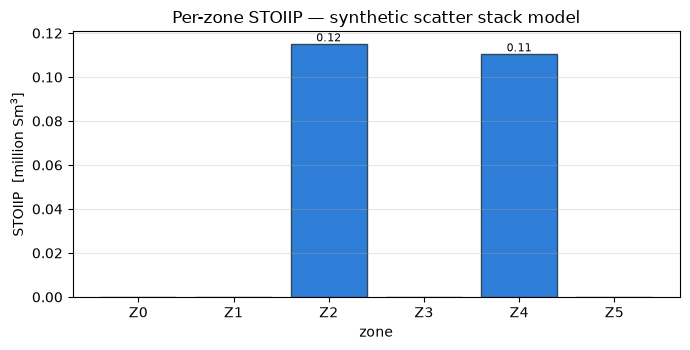

In [4]:
import matplotlib.pyplot as plt

names   = [z["zone"] for z in zones]
stoiip  = [z["stoiip_msm3"] for z in zones]
oil     = [s > 0 for s in stoiip]
colors  = ["#2f7ed8" if o else "#c9d2dd" for o in oil]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(names, stoiip, color=colors, edgecolor="#33475b")
ax.set_ylabel("STOIIP  [million Sm$^3$]")
ax.set_xlabel("zone")
ax.set_title("Per-zone STOIIP — synthetic scatter stack model")
ax.grid(axis="y", alpha=0.3)
for i, s in enumerate(stoiip):
    if s > 0:
        ax.text(i, s, f"{s:.2f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
plt.show()


## Recap

From synthetic **scatter** we conditioned a horizon stack, built a convergent corner-point grid, populated deterministic property cubes, and read per-zone OOIP straight off the `StaticModel`. Notebook 02 takes the same model into a GRV/in-place table, a **contact scenario**, and the JSON view bundles.